# Aligned compactness comparison

Same analysis as `compare_beta.ipynb`, but every run is **time-shifted at load time**
so that the minimum compactness (strongest collapse, found for $\ln(a)>$ `LNA_MIN_SEARCH`)
is aligned to a common reference $\ln(a)=$ `ALIGN_LNA`.

All subsequent plots and statistics are computed on the **shifted** time axis only.

In [1]:
import sys, os, re, glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs


## 0 — Alignment parameters

Tweak these before loading. The alignment procedure:
1. For each run, find the **minimum** of $\mathcal{C}$ for $\ln(a) >$ `LNA_MIN_SEARCH`.
2. Shift the entire $\ln(a)$ axis so that this minimum sits at `ALIGN_LNA`.
3. Store the shifted axis as `shifted_ln_a` alongside the original.

In [2]:
ALIGN_LNA = 2.0           # target ln(a) for the compactness minimum
LNA_MIN_SEARCH = 0.0      # only search for the minimum after this value

# Compactness statistics window (on the SHIFTED axis)
#LN_A_COMP_MIN = 2
#LN_A_COMP_MAX = 3.1

LN_A_COMP_MIN = 2
LN_A_COMP_MAX = 3.5

# Grid / MG parameters (same for all runs)
scalar_mu = 1
r_max = 150
min_dr = 1 / 16
max_dr = 2
a_mg = 0.2
b_mg = 0.4
chi0 = 0.15

## 1 — Discover, load, and align all runs

Each run is loaded once, diagnostics are computed or read from cache,
and the time shift is applied immediately.

In [3]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c) #we calculate also the standard deviation

all_runs = {}   # key = (lgb, mu, beta, amp, width)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    beta = float(m_beta.group(1)) if m_beta else 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)

    # ── Compute shift and store shifted axis ─────────────────────────────
    peak_lna = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - peak_lna if not np.isnan(peak_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width)
    all_runs[key] = dict(
        osc=osc, t=t, tag=tag, lgb=lgb, mu=mu, beta=beta,
        coupling=coupling, amp=amp, width=width,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.395  C=7.8271e-03 [4.4912e-03, 1.5807e-02]  (1000 steps)
  lgb= -10.0, mu=0.08,    beta=10, A=-0.02, R=3.0  shift=+0.286  C=7.3775e-03 [4.0808e-03, 1.4786e-02]  (1000 steps)
  lgb= -15.0, mu=0.08,    beta=10, A=-0.02, R=3.0  shift=+0.230  C=7.0151e-03 [3.8429e-03, 1.3776e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.399  C=7.7194e-03 [4.4692e-03, 1.5634e-02]  (1000 steps)
  lgb= -20.0, mu=0.08,    beta=10, A=-0.02, R=3.0  shift=+1.926  C=4.1002e+00 [4.1002e+00, 4.1002e+00]  (3 steps)
  lgb= -25.0, mu=0.08,    beta=10, A=-0.02, R=3.0  shift=+1.926  C=4.1167e+00 [4.1167e+00, 4.1167e+00]  (3 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.351  C=7.7846e-03 [4.3800e-03, 1.5326e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.350  C=7.6904e-03 [4.3240e-03, 1.5155e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.354  C=7.5

## 2 — Select runs to plot

Filter which `(lgb, mu, beta, amp, width)` keys appear on the plots.

In [18]:
#DEFAULT_AMP   = -0.02
DEFAULT_AMP   = -0.02
DEFAULT_WIDTH = 3.0

betas = [0]
betaval = betas[0]

mu_values = [0.08]
lijst = [-15, -10, -5, 0, 5, 10, 15]

selected = [
    k for k in all_runs
    #if k[2] == betaval  
    if k[2] in betas 
    #if k[2] == 0 and k[2] ==50
    #and k[0] in lijst
    and 13>k[0] >11
    and k[1] in mu_values
    and k[3] == DEFAULT_AMP and k[4] == DEFAULT_WIDTH
]
# selected = None  # uncomment to plot all

keys_to_plot = sorted(all_runs.keys()) if selected is None else selected
print(f"{len(keys_to_plot)} run(s) selected")
for k in keys_to_plot:
    d = all_runs[k]
    print(f"  {k}  shift={d['shift']:+.3f}  C_mean={d['C_mean']:.4e}")

1 run(s) selected
  (12.0, 0.08, 0.0, -0.02, 3.0)  shift=+0.548  C_mean=8.7655e-03


## 3 — Aligned compactness time series

All curves use `shifted_ln_a` computed during loading.

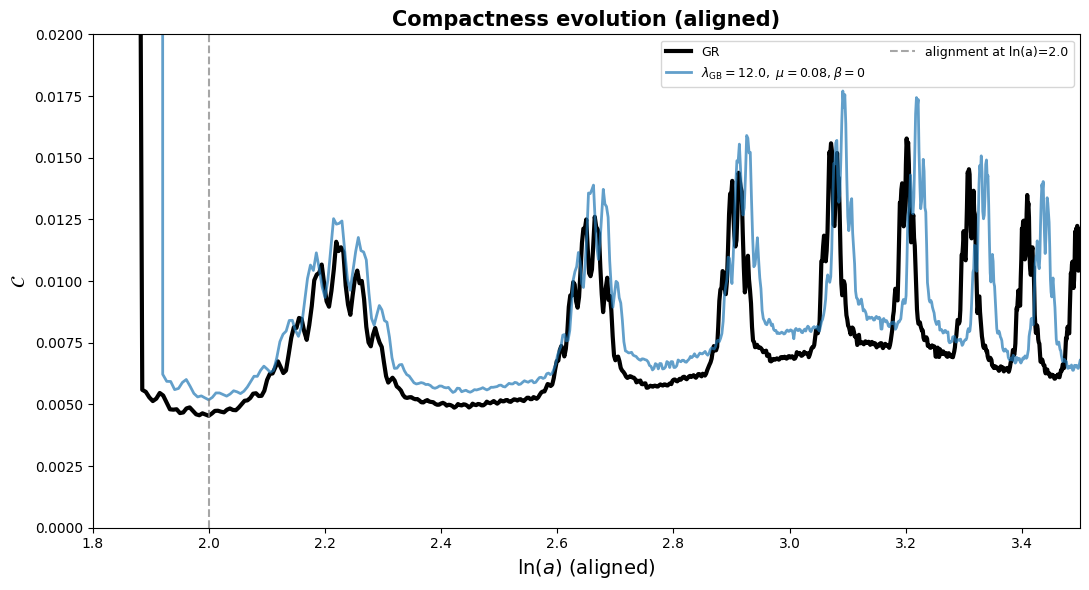

In [39]:
USE_ALIGNED = True  # True = shifted ln(a), False = original ln(a)

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10 #Multiple colors
#cmap = plt.cm.Blues #Single color
n_runs = len(keys_to_plot)

gr_key = (0.0, 0.08, 250.0, DEFAULT_AMP, DEFAULT_WIDTH)

if gr_key in all_runs and gr_key not in keys_to_plot:
    gr = all_runs[gr_key]
    xgr = gr["shifted_ln_a"] if USE_ALIGNED else gr["osc"]["ln_a"]
    ax.plot(xgr, gr["osc"]["C"], color="k", lw=3, label="GR", alpha=1)

for i, key in enumerate(keys_to_plot):
    if key not in all_runs:
        continue
    data = all_runs[key]
    lgb, mu, beta, amp, width = key

    beta_str = f", \\beta={int(beta)}" if beta is not None and beta != 250 else ""
    if lgb == 0.0:
        label = f"GR, $\\mu={mu}$"
    else:
        label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\mu={mu}{beta_str}$"

    color = cmap(i % 10) #Multiple colors
    #color = cmap(0.3 + 0.7 * i / max(n_runs - 1, 1)) #Single color

    xdata = data["shifted_ln_a"] if USE_ALIGNED else data["osc"]["ln_a"]
    ax.plot(xdata, data["osc"]["C"],
            color=color, lw=2, label=label, alpha=0.7)



if USE_ALIGNED:
    ax.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.5, alpha=0.7,
               label=f"alignment at ln(a)={ALIGN_LNA}")

ax.set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED else ""), fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
ax.set_xlim(1.8, 3.5)
#ax.set_xlim(-2, 3.5)
ax.set_ylim(0, 0.02)
ax.set_title("Compactness evolution" + (" (aligned)" if USE_ALIGNED else ""),
             fontsize=15, fontweight="bold")
ax.legend(fontsize=9, ncol=2, loc="best")
fig.tight_layout()
plt.show()

## 4 — Compactness vs $\lambda_{\rm GB}$ (aligned)

Mean compactness (with min–max error bars) computed in the shifted window
$[$ `LN_A_COMP_MIN` $,$ `LN_A_COMP_MAX` $]$.

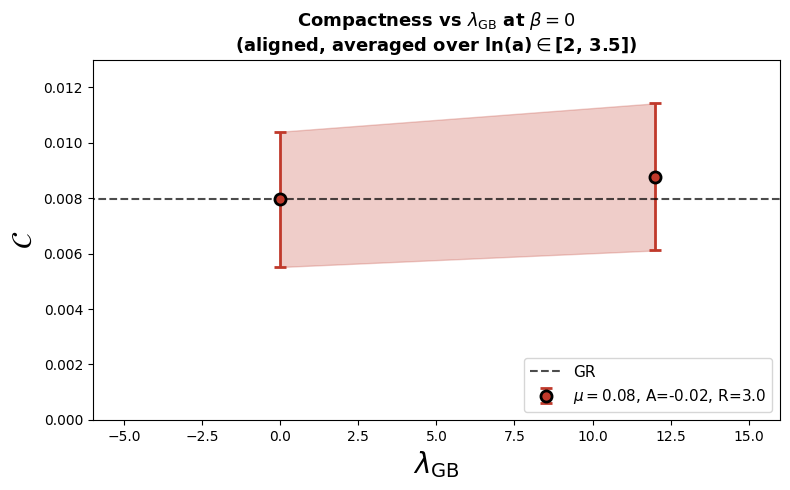

In [40]:
colors_p  = ["#c0392b", "#27ae60", "#2980b9"]
markers_p = ["o", "v", "s"]

fig, ax = plt.subplots(figsize=(8, 5))

points = []

# GR point
gr_key = (0.0, 0.08, 250.0, DEFAULT_AMP, DEFAULT_WIDTH)
if gr_key in all_runs:
    d_gr = all_runs[gr_key]
    if not np.isnan(d_gr["C_mean"]):
        points.append((0.0, d_gr["C_mean"], d_gr["C_min"], d_gr["C_max"], d_gr["C_std"]))

for key in keys_to_plot:
    if key not in all_runs or key[0] == 0.0:
        continue
    d = all_runs[key]
    if np.isnan(d["C_mean"]):
        continue
    points.append((key[0], d["C_mean"], d["C_min"], d["C_max"], d["C_std"]))

if points:
    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_min  = np.array([p[2] for p in points])
    y_max  = np.array([p[3] for p in points])
    y_std  = np.array([p[4] for p in points])
    """
    # Min-max error bars 
    ax.fill_between(x, y_min, y_max, color=colors_p[0], alpha=0.25)
    ax.errorbar(x, y_mean,
                yerr=[y_mean - y_min, y_max - y_mean],
                fmt=markers_p[0], color=colors_p[0],
                markeredgecolor="k", markeredgewidth=2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=8,
                label=f"$\\mu=0.08$, A={DEFAULT_AMP}, R={DEFAULT_WIDTH}")
    """
    # Standard deviation error bars
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=colors_p[0], alpha=0.25)
    ax.errorbar(x, y_mean,
                yerr=y_std,
                fmt=markers_p[0], color=colors_p[0],
                markeredgecolor="k", markeredgewidth=2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=8,
                label=f"$\\mu=0.08$, A={DEFAULT_AMP}, R={DEFAULT_WIDTH}")
    
ax.set_xlabel(r"$\lambda_{\rm GB}$", fontsize=20)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=20)
ax.set_title(
    f"Compactness vs $\\lambda_{{\\rm GB}}$ at $\\beta={betaval}$\n"
    f"(aligned, averaged over ln(a)$\\in$[{LN_A_COMP_MIN}, {LN_A_COMP_MAX}])",
    fontsize=13, fontweight="bold")

ax.hlines(d_gr["C_mean"], -18, 18, color="k", linestyle="--", alpha=0.7, label="GR")
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim(-6, 16)
ax.set_ylim(0, 1.3e-2)
fig.tight_layout()
plt.show()

## 5 — Energy density & Gauss-Bonnet invariant vs radius

Pick a run and choose snapshot times on the **shifted** axis.
If `full_L_GB` is available it is used; otherwise `bar_L_GB`.

full_L_GB available.
Snapshots: ['ln(a)=2.000', 'ln(a)=2.180', 'ln(a)=3.000']


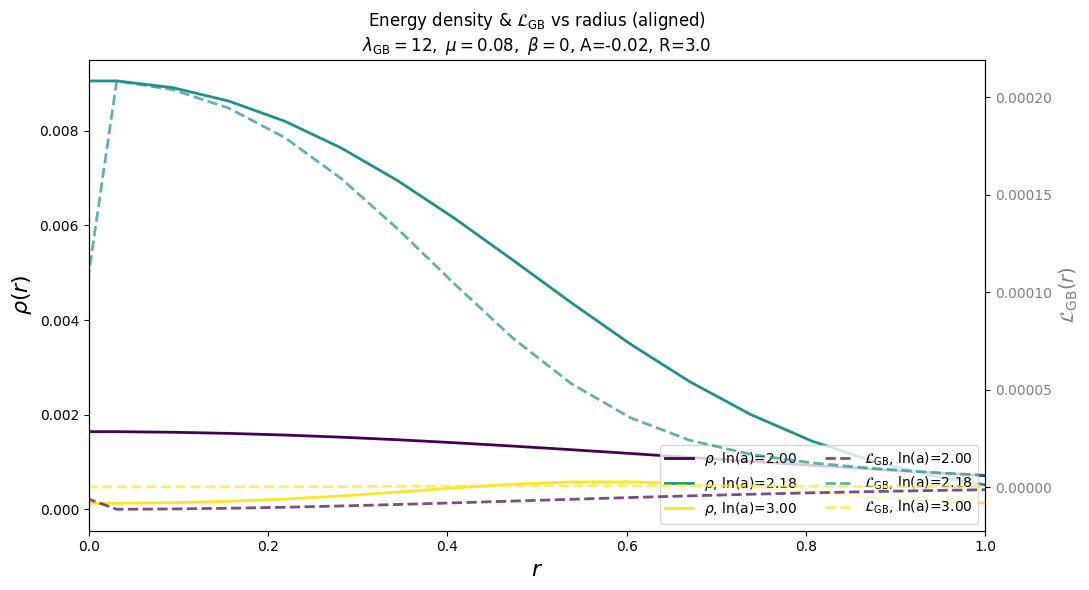

In [45]:
lambdagb = 12

plot_key   = (lambdagb, 0.08, 0, -0.02, 3.0)
r_plot_max  = 30.0

# Pick exact shifted ln(a) values for snapshots (closest available time step is used)
snapshot_lna_values = [2, 2.18, 3]
#snapshot_lna_values = [2.16, 2.17, 2.18, 2.19, 2.2]

# ── Load / recompute if full_L_GB missing ────────────────────────────────
run_data = all_runs[plot_key]
osc      = run_data["osc"]
r_grid   = osc["r"]
s_ln_a   = run_data["shifted_ln_a"]

has_full = "full_L_GB" in osc and np.any(osc["full_L_GB"] != 0)
if not has_full:
    print("full_L_GB missing — recomputing from solution.npy ...")
    lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
    run_dir = os.path.join(DATA_DIR, run_data["tag"])
    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t_arr = np.load(os.path.join(run_dir, "t.npy"))
    matter_p  = ScalarMatter(scalar_mu, mu_p)
    sv_p      = StateVector(matter_p)
    spacing_p = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_p    = Grid(spacing_p, sv_p)
    bg_p      = FlatSphericalBackground(grid_p.r)
    params_p  = (lgb_p, a_mg, b_mg, chi0, run_data["coupling"])
    osc = get_oscillon_diagnostic(
        sol, t_arr, grid_p, bg_p,
        ScalarMatter(scalar_mu, mu_p),
        params_p, surface_threshold=0.05, r_max_diag=100.0,
    )
    np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)
    run_data["osc"] = osc
    r_grid = osc["r"]
    s_ln_a = osc["ln_a"] + run_data["shift"]
    run_data["shifted_ln_a"] = s_ln_a
    del sol
    print("Done.")
else:
    print("full_L_GB available.")

# ── Select snapshots: find closest time step to each requested ln(a) ─────
snap_indices = np.array([np.argmin(np.abs(s_ln_a - v)) for v in snapshot_lna_values])
n_snapshots = len(snap_indices)
print("Snapshots:", [f"ln(a)={s_ln_a[i]:.3f}" for i in snap_indices])

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

r_mask = r_grid <= r_plot_max
cmap_snap = plt.cm.viridis

lgb_key = "full_L_GB" if ("full_L_GB" in osc and np.any(osc["full_L_GB"] != 0)) else "bar_L_GB"

for j, idx in enumerate(snap_indices):
    color = cmap_snap(j / max(n_snapshots - 1, 1))
    lna_val = s_ln_a[idx]

    ax1.plot(r_grid[r_mask], osc["rho"][idx][r_mask],
             color=color, lw=2,
             label=f"$\\rho$, ln(a)={lna_val:.2f}")

    if lgb_key in osc:
        ax2.plot(r_grid[r_mask], osc[lgb_key][idx][r_mask],
                 color=color, lw=2, ls="--", alpha=0.7,
                 label=f"$\\mathcal{{L}}_{{\\rm GB}}$, ln(a)={lna_val:.2f}")

lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
ax1.set_xlabel(r"$r$", fontsize=16)
ax1.set_ylabel(r"$\rho(r)$", fontsize=16, color="k")
ax2.set_ylabel(r"$\mathcal{L}_{\rm GB}(r)$", fontsize=14, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax1.set_title(
    f"Energy density & $\\mathcal{{L}}_{{\\rm GB}}$ vs radius (aligned)\n"
    f"$\\lambda_{{\\rm GB}}={lgb_p},\\ \\mu={mu_p},\\ \\beta={int(beta_p)}$, "
    f"A={amp_p}, R={width_p}",
    fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, ncol=2, loc="lower right")
ax1.set_xlim(0, 1)
fig.tight_layout()
plt.show()

## 6 — Scalar field $\phi(r)$ profile

Same snapshots as the energy density plot above.

(12, 0.08, 0, -0.02, 3.0)


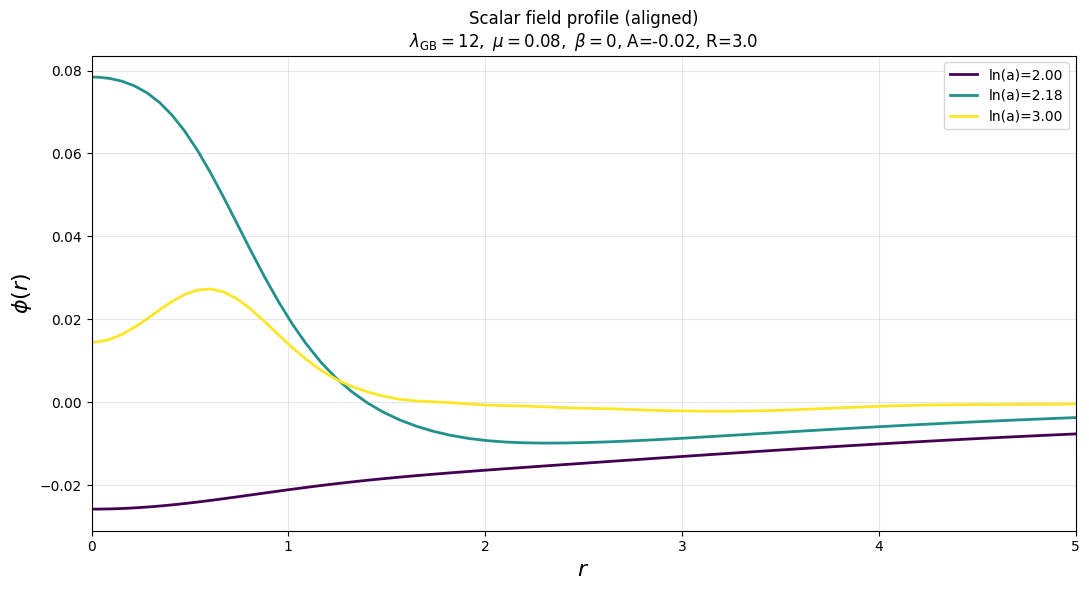

In [52]:
print(plot_key)
(-5, 0.08, 0, -0.02, 3.0)
#lgb_p, mu_p, beta_p, amp_p, width_p = plot_key

lgb_p, mu_p, beta_p, amp_p, width_p = (12, 0.08, 0, -0.02, 3.0)
tag = run_data["tag"]
run_dir = os.path.join(DATA_DIR, tag)

sol = np.load(os.path.join(run_dir, "solution.npy"))
N_grid = len(r_grid)
NUM_VARS = sol.shape[1] // N_grid

fig, ax = plt.subplots(figsize=(11, 6))
r_mask = r_grid <= r_plot_max
cmap_snap = plt.cm.viridis

for j, idx in enumerate(snap_indices):
    state = sol[idx].reshape(NUM_VARS, N_grid)
    u_field = state[12]
    color = cmap_snap(j / max(n_snapshots - 1, 1))
    lna_val = s_ln_a[idx]
    ax.plot(r_grid[r_mask], u_field[r_mask], color=color, lw=2,
            label=f"ln(a)={lna_val:.2f}")

ax.set_xlabel(r"$r$", fontsize=16)
ax.set_ylabel(r"$\phi(r)$", fontsize=16)
ax.set_title(
    f"Scalar field profile (aligned)\n"
    f"$\\lambda_{{\\rm GB}}={lgb_p},\\ \\mu={mu_p},\\ \\beta={int(beta_p)}$, "
    f"A={amp_p}, R={width_p}",
    fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.set_xlim(0, 5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

del sol

## 7 — Effective potential $V_{\rm eff}(\phi)$

Uses $\mathcal{L}_{\rm GB}(r=0)$ from the simulation at the chosen snapshot.

Snapshot 140 (shifted ln(a)=2.18): L_GB(r=0) = 1.0628e-05  (using full_L_GB)


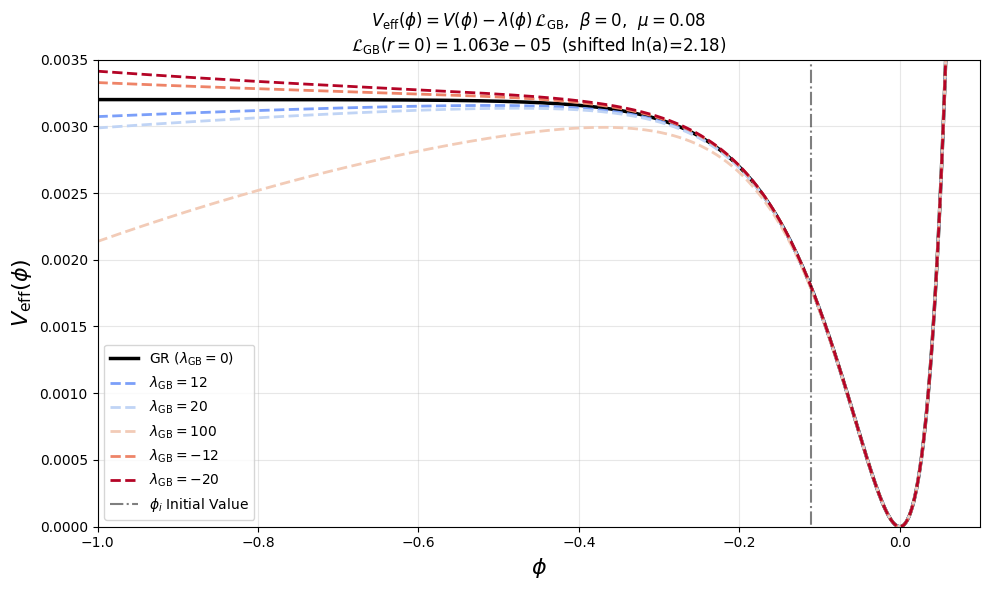

In [51]:
lambda_values = [0, 12, 20, 100, -12, -20]

lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
m = scalar_mu
f = mu_p

snap_idx = snap_indices[1]
r_grid_veff = osc["r"]
center_idx  = np.argmin(np.abs(r_grid_veff))

lgb_key_veff = "full_L_GB" if ("full_L_GB" in osc and np.any(osc["full_L_GB"] != 0)) else "bar_L_GB"
L_GB_center = osc[lgb_key_veff][snap_idx, center_idx]
print(f"Snapshot {snap_idx} (shifted ln(a)={s_ln_a[snap_idx]:.2f}): "
      f"L_GB(r=0) = {L_GB_center:.4e}  (using {lgb_key_veff})")

phi = np.linspace(-1.0, 0.1, 500)
V = 0.5 * m**2 * f**2 * (1.0 - np.exp(phi / f))**2

fig, ax = plt.subplots(figsize=(10, 6))
cmap_veff = plt.cm.coolwarm

for i, lgb_val in enumerate(lambda_values):
    if beta_p == 0:
        lam_phi = lgb_val * phi**2
    else:
        lam_phi = -lgb_val / beta_p * np.exp(-beta_p * phi**2)

    V_eff = V - lam_phi * L_GB_center

    if lgb_val == 0:
        ax.plot(phi, V_eff, color="black", lw=2.5,
                label=r"GR ($\lambda_{\rm GB}=0$)")
    else:
        color = cmap_veff(i / max(len(lambda_values) - 1, 1))
        ax.plot(phi, V_eff, color=color, lw=2, ls="--",
                label=rf"$\lambda_{{\rm GB}}={lgb_val}$")

ax.set_xlabel(r"$\phi$", fontsize=16)
ax.set_ylabel(r"$V_{\rm eff}(\phi)$", fontsize=16)
ax.set_title(
    r"$V_{\rm eff}(\phi) = V(\phi) - \lambda(\phi)\,\mathcal{L}_{\rm GB}$"
    + f",  $\\beta={int(beta_p)}$,  $\\mu={f}$\n"
    + f"$\\mathcal{{L}}_{{\\rm GB}}(r=0)={L_GB_center:.3e}$"
    + f"  (shifted ln(a)={s_ln_a[snap_idx]:.2f})",
    fontsize=12)
ax.vlines(-1.10495e-1, -1, 0.1, color="k", linestyle="-.", alpha=0.5, label=r"$\phi_i$ Initial Value")
ax.legend(fontsize=10, loc="best")
ax.set_xlim(-1, 0.1)
#ax.set_xlim(-0.2, 0.1)
ax.set_ylim(0.0015, 0.0035)
ax.set_ylim(0., 0.0035)

ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()